---

# **Perceptron Demonstration**

---

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-deep-learning/refs/heads/main/day3/placement.csv')

In [12]:
print(df.shape)
df.head()

(100, 3)


,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


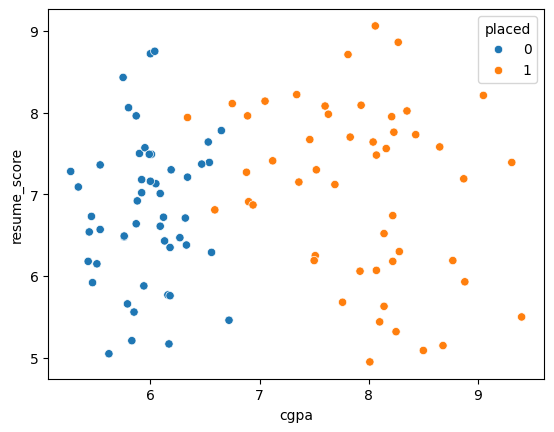

In [15]:
sns.scatterplot(x='cgpa', y='resume_score', hue='placed', data=df)
plt.show()


In [16]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [17]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [18]:
p.fit(X,y)

Perceptron()

In [19]:
p.coef_

array([[ 40.26, -36.  ]])

In [20]:
p.intercept_

array([-25.])

In [21]:
from mlxtend.plotting import plot_decision_regions

/workspaces/Data-Science-Materials/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


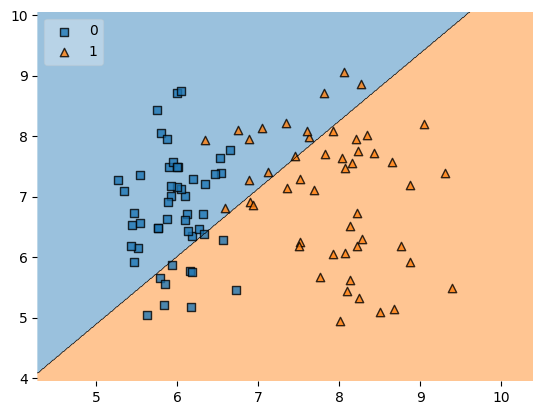

In [22]:
plot_decision_regions(X.values, y.values, clf=p, legend=2)
plt.show()

---

# **Perceptron Trick**

---

In [24]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

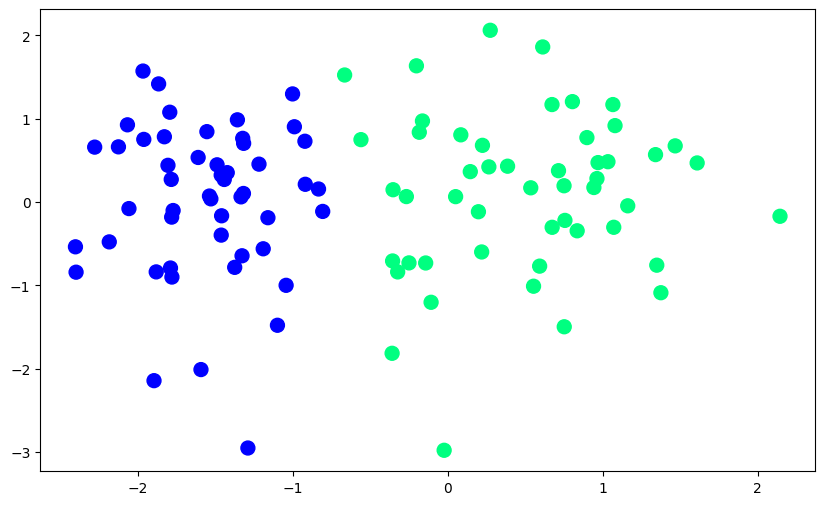

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [28]:
def step(z):
    return 1 if z>0 else 0

In [29]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [30]:
intercept_,coef_ = perceptron(X,y)

In [31]:
print(coef_)
print(intercept_)

[1.38016177 0.1041313 ]
1.0


In [32]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [33]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

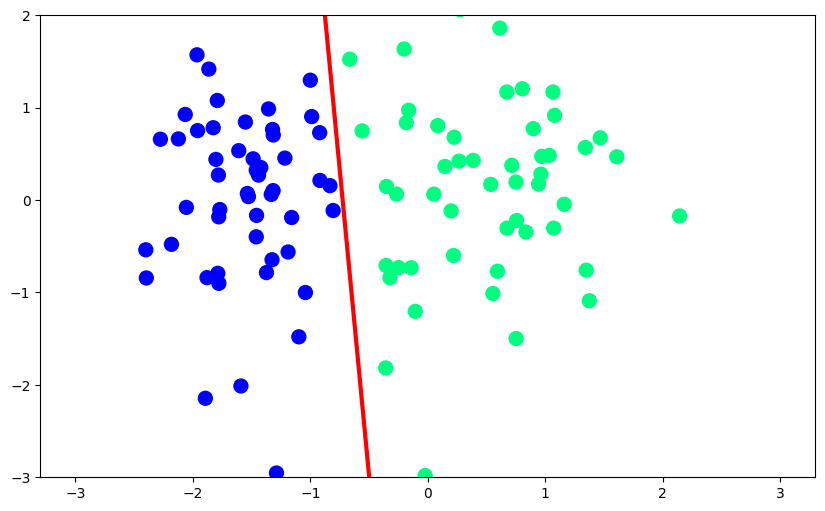

In [34]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()

---